# End-to-End Exploratory Data Analysis: Healthcare Insurance Coverage Dataset

## Objective: Perform a complete EDA on coverage rates before and after the Affordable Care Act to understand the data, clean it, and uncover patterns related to coverage claims.

## Dataset: states.csv 

# Project Roadmap
1. Data Understanding
2. Statistical analysis
3. Data Cleaning
4. Univariate Analysis
5. Bivariate Analysis
6. Multivariate Analysis
7. Outlier Analysis (Deep Dive)
8. Key Insights & Conclusion

## 0. Setup & Imports

In [ ]:
pip install numpy pandas matplotlib seaborn

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
import warnings
warnings.filterwarnings("ignore")

## 1. Data Understanding
It helps to summarize the size of the dataset, whats inside the data. what are the missing values and also for evaluating the quality of the dataset

In [5]:
df = pd.read_csv('C:\\Users\\Ankan Mukherjee\\OneDrive\\Desktop\\anisha ai ml\\states.csv')

df.head()

,State,Uninsured Rate (2010),Uninsured Rate (2015),Uninsured Rate Change (2010-2015),Health Insurance Coverage Change (2010-2015),Employer Health Insurance Coverage (2015),Marketplace Health Insurance Coverage (2016),Marketplace Tax Credits (2016),Average Monthly Tax Credit (2016),State Medicaid Expansion (2016),Medicaid Enrollment (2013),Medicaid Enrollment (2016),Medicaid Enrollment Change (2013-2016),Medicare Enrollment (2016)
0,Alabama,14.6%,10.1%,-4.5%,215000,2545000,165534,152206,$310,False,799176.0,910775,111599.0,989855
1,Alaska,19.9%,14.9%,-5%,36000,390000,17995,16205,$750,True,122334.0,166625,44291.0,88966
2,Arizona,16.9%,10.8%,-6.1%,410000,3288000,179445,124346,$230,True,1201770.0,1716198,514428.0,1175624
3,Arkansas,17.5%,9.5%,-8%,234000,1365000,63357,56843,$306,True,556851.0,920194,363343.0,606146
4,California,18.5%,8.6%,-9.9%,3826000,19552000,1415428,1239893,$309,True,7755381.0,11843081,4087700.0,5829777


In [6]:
df.tail ()

,State,Uninsured Rate (2010),Uninsured Rate (2015),Uninsured Rate Change (2010-2015),Health Insurance Coverage Change (2010-2015),Employer Health Insurance Coverage (2015),Marketplace Health Insurance Coverage (2016),Marketplace Tax Credits (2016),Average Monthly Tax Credit (2016),State Medicaid Expansion (2016),Medicaid Enrollment (2013),Medicaid Enrollment (2016),Medicaid Enrollment Change (2013-2016),Medicare Enrollment (2016)
47,Washington,14.2%,6.6%,-7.6%,537000,3986000,158245,110476,$238,True,1117576.0,1788536,670960.0,1238649
48,West Virginia,14.6%,6%,-8.6%,156000,976000,33235,29163,$388,True,354544.0,575645,221101.0,423500
49,Wisconsin,9.4%,5.7%,-3.7%,211000,3521000,224208,190542,$332,False,985531.0,1046897,61366.0,1084854
50,Wyoming,14.9%,11.5%,-3.4%,20000,335000,22076,20313,$459,False,67518.0,63583,-3935.0,99128
51,United States,15.5%,9.4%,6.1%,19304000,172292000,11081330,9389609,$291,NaN,56392477.0,73532931,16106157.0,57149984


In [7]:
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

Shape: 52 rows x 14 columns


### 1.1 Structure & Data Types


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 14 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   State                                         52 non-null     str    
 1   Uninsured Rate (2010)                         52 non-null     str    
 2   Uninsured Rate (2015)                         52 non-null     str    
 3   Uninsured Rate Change (2010-2015)             52 non-null     str    
 4   Health Insurance Coverage Change (2010-2015)  52 non-null     int64  
 5   Employer Health Insurance Coverage (2015)     52 non-null     int64  
 6   Marketplace Health Insurance Coverage (2016)  52 non-null     int64  
 7   Marketplace Tax Credits (2016)                52 non-null     int64  
 8   Average Monthly Tax Credit (2016)             52 non-null     str    
 9   State Medicaid Expansion (2016)               51 non-null     object 
 10  Med

From the above information it is clear that 
1. State Medicaid Expansion has 1 null value
2. Medicaid Enrollment (2013) has 2 null values
3. Medicaid Enrollment Change (2013-2016) has 2 null values
4. Average Monthly Tax Credit has wrong data type


### 1.2 Column Dictionary


In [11]:
df.columns

Index(['State', 'Uninsured Rate (2010)', 'Uninsured Rate (2015)',
       'Uninsured Rate Change (2010-2015)',
       'Health Insurance Coverage Change (2010-2015)',
       'Employer Health Insurance Coverage (2015)',
       'Marketplace Health Insurance Coverage (2016)',
       'Marketplace Tax Credits (2016)', 'Average Monthly Tax Credit (2016)',
       'State Medicaid Expansion (2016)', 'Medicaid Enrollment (2013)',
       'Medicaid Enrollment (2016)', 'Medicaid Enrollment Change (2013-2016)',
       'Medicare Enrollment (2016)'],
      dtype='str')

## 2. Statistical Analysis
This method gives the overall descriptive summary of the dataframe. This works only for numerical columns

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Health Insurance Coverage Change (2010-2015),52.0,7.479423e+05,2.691466e+06,15000.0,97250.00,224500.0,412250.00,19304000.0
Employer Health Insurance Coverage (2015),52.0,6.626615e+06,2.370240e+07,335000.0,879750.00,2305500.0,4386500.00,172292000.0
Marketplace Health Insurance Coverage (2016),52.0,4.262050e+05,1.538234e+06,13313.0,51097.00,130672.5,226082.25,11081330.0
Marketplace Tax Credits (2016),52.0,3.611388e+05,1.306590e+06,1224.0,43717.00,98175.5,193684.50,9389609.0
Medicaid Enrollment (2013),50.0,2.255699e+06,7.945644e+06,67518.0,289775.00,794613.5,1274017.25,56392477.0
Medicaid Enrollment (2016),52.0,2.828190e+06,1.017933e+07,63583.0,309112.75,978052.5,1732723.75,73532931.0
Medicaid Enrollment Change (2013-2016),50.0,6.442463e+05,2.306655e+06,-3935.0,53979.00,234156.0,456249.25,16106157.0
Medicare Enrollment (2016),52.0,2.173923e+06,7.855834e+06,88966.0,320887.00,818753.0,1298255.25,57149984.0


From the above description it looks that:
1. Positive outliers are being seen in the dataset 
2. Need to check with boxplot 

In [23]:
df.describe(include="object").T


,count,unique,top,freq
State,52,52,Alabama,1
Uninsured Rate (2010),52,46,14.6%,2
Uninsured Rate (2015),52,43,6%,3
Uninsured Rate Change (2010-2015),52,40,-4.8%,4
Average Monthly Tax Credit (2016),52,47,$306,3
State Medicaid Expansion (2016),52,3,True,32


## 3. Data Cleaning

### 3.1 Data types

In [10]:
df.dtypes

State                                               str
Uninsured Rate (2010)                               str
Uninsured Rate (2015)                               str
Uninsured Rate Change (2010-2015)                   str
Health Insurance Coverage Change (2010-2015)      int64
Employer Health Insurance Coverage (2015)         int64
Marketplace Health Insurance Coverage (2016)      int64
Marketplace Tax Credits (2016)                    int64
Average Monthly Tax Credit (2016)                   str
State Medicaid Expansion (2016)                  object
Medicaid Enrollment (2013)                      float64
Medicaid Enrollment (2016)                        int64
Medicaid Enrollment Change (2013-2016)          float64
Medicare Enrollment (2016)                        int64
dtype: object

### 3.2 Finding Duplicated Values

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop_duplicates()

,State,Uninsured Rate (2010),Uninsured Rate (2015),Uninsured Rate Change (2010-2015),Health Insurance Coverage Change (2010-2015),Employer Health Insurance Coverage (2015),Marketplace Health Insurance Coverage (2016),Marketplace Tax Credits (2016),Average Monthly Tax Credit (2016),State Medicaid Expansion (2016),Medicaid Enrollment (2013),Medicaid Enrollment (2016),Medicaid Enrollment Change (2013-2016),Medicare Enrollment (2016)
0,Alabama,14.6%,10.1%,-4.5%,215000,2545000,165534,152206,$310,False,799176.0,910775,111599.0,989855
1,Alaska,19.9%,14.9%,-5%,36000,390000,17995,16205,$750,True,122334.0,166625,44291.0,88966
2,Arizona,16.9%,10.8%,-6.1%,410000,3288000,179445,124346,$230,True,1201770.0,1716198,514428.0,1175624
3,Arkansas,17.5%,9.5%,-8%,234000,1365000,63357,56843,$306,True,556851.0,920194,363343.0,606146
4,California,18.5%,8.6%,-9.9%,3826000,19552000,1415428,1239893,$309,True,7755381.0,11843081,4087700.0,5829777
5,Colorado,15.9%,8.1%,-7.8%,419000,2949000,108311,67062,$318,True,783420.0,1375264,591844.0,820234
6,Connecticut,9.1%,6%,-3.1%,110000,2148000,102917,80759,$357,True,NaN,761137,NaN,644136
7,Delaware,9.7%,5.9%,-3.8%,35000,564000,25379,21467,$330,True,223324.0,236702,13378.0,186835
8,District of Columbia,7.6%,3.8%,-3.8%,25000,388000,17666,1224,$183,True,235786.0,255491,19705.0,90492
9,Florida,21.3%,13.3%,-8%,1597000,8847000,1531714,1428712,$305,False,3104996.0,3644673,539677.0,4149593


In [76]:
df_cleaned = df.drop(df.index[50])

In [80]:
target_cols = ['Uninsured Rate (2010)', 'Uninsured Rate (2015)', 'Uninsured Rate Change (2010-2015)']
for col in target_cols:
    df_cleaned[col] = df_cleaned[col].str.replace('%', '', regex=False).astype(float) / 100


In [82]:

df_cleaned['Average Monthly Tax Credit (2016)'] = df_cleaned['Average Monthly Tax Credit (2016)'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)


Here I have removed the United States row, as it was the aggregate of all the states creating redundancy within the value. In addition to this, I have cleaned the percentage values and the dollar values to float. 

In [84]:
ndf = df_cleaned
print (ndf)

                   State  Uninsured Rate (2010)  Uninsured Rate (2015)  \
0               Alabama                   0.146                  0.101   
1                Alaska                   0.199                  0.149   
2               Arizona                   0.169                  0.108   
3              Arkansas                   0.175                  0.095   
4             California                  0.185                  0.086   
5               Colorado                  0.159                  0.081   
6            Connecticut                  0.091                  0.060   
7              Delaware                   0.097                  0.059   
8   District of Columbia                  0.076                  0.038   
9               Florida                   0.213                  0.133   
10              Georgia                   0.197                  0.139   
11                Hawaii                  0.079                  0.040   
12                 Idaho              

In [85]:
ndf.head()

,State,Uninsured Rate (2010),Uninsured Rate (2015),Uninsured Rate Change (2010-2015),Health Insurance Coverage Change (2010-2015),Employer Health Insurance Coverage (2015),Marketplace Health Insurance Coverage (2016),Marketplace Tax Credits (2016),Average Monthly Tax Credit (2016),State Medicaid Expansion (2016),Medicaid Enrollment (2013),Medicaid Enrollment (2016),Medicaid Enrollment Change (2013-2016),Medicare Enrollment (2016)
0,Alabama,0.146,0.101,-0.045,215000,2545000,165534,152206,310.0,False,799176.0,910775,111599.0,989855
1,Alaska,0.199,0.149,-0.050,36000,390000,17995,16205,750.0,True,122334.0,166625,44291.0,88966
2,Arizona,0.169,0.108,-0.061,410000,3288000,179445,124346,230.0,True,1201770.0,1716198,514428.0,1175624
3,Arkansas,0.175,0.095,-0.080,234000,1365000,63357,56843,306.0,True,556851.0,920194,363343.0,606146
4,California,0.185,0.086,-0.099,3826000,19552000,1415428,1239893,309.0,True,7755381.0,11843081,4087700.0,5829777


### 3.3 Finding null values

In [86]:
ndf.isnull()

,State,Uninsured Rate (2010),Uninsured Rate (2015),Uninsured Rate Change (2010-2015),Health Insurance Coverage Change (2010-2015),Employer Health Insurance Coverage (2015),Marketplace Health Insurance Coverage (2016),Marketplace Tax Credits (2016),Average Monthly Tax Credit (2016),State Medicaid Expansion (2016),Medicaid Enrollment (2013),Medicaid Enrollment (2016),Medicaid Enrollment Change (2013-2016),Medicare Enrollment (2016)
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [87]:
ndf.isnull().sum()

State                                           0
Uninsured Rate (2010)                           0
Uninsured Rate (2015)                           0
Uninsured Rate Change (2010-2015)               0
Health Insurance Coverage Change (2010-2015)    0
Employer Health Insurance Coverage (2015)       0
Marketplace Health Insurance Coverage (2016)    0
Marketplace Tax Credits (2016)                  0
Average Monthly Tax Credit (2016)               0
State Medicaid Expansion (2016)                 0
Medicaid Enrollment (2013)                      0
Medicaid Enrollment (2016)                      0
Medicaid Enrollment Change (2013-2016)          0
Medicare Enrollment (2016)                      0
dtype: int64

In [88]:
ndf.isnull().sum()/ndf.shape[0]*100

State                                           0.0
Uninsured Rate (2010)                           0.0
Uninsured Rate (2015)                           0.0
Uninsured Rate Change (2010-2015)               0.0
Health Insurance Coverage Change (2010-2015)    0.0
Employer Health Insurance Coverage (2015)       0.0
Marketplace Health Insurance Coverage (2016)    0.0
Marketplace Tax Credits (2016)                  0.0
Average Monthly Tax Credit (2016)               0.0
State Medicaid Expansion (2016)                 0.0
Medicaid Enrollment (2013)                      0.0
Medicaid Enrollment (2016)                      0.0
Medicaid Enrollment Change (2013-2016)          0.0
Medicare Enrollment (2016)                      0.0
dtype: float64

From the above result, it is clear that none of the columns have null values more than 25%. So we dont need to drop any columns 

### 3.3 Filling null values

In [89]:
ndf["State Medicaid Expansion (2016)"]=ndf["State Medicaid Expansion (2016)"].fillna(ndf["State Medicaid Expansion (2016)"].mean())

In [90]:
ndf["Medicaid Enrollment (2013)"]=ndf["Medicaid Enrollment (2013)"].fillna(ndf["Medicaid Enrollment (2013)"].mean())

In [91]:
ndf["Medicaid Enrollment Change (2013-2016)"]=ndf["Medicaid Enrollment Change (2013-2016)"].fillna(ndf["Medicaid Enrollment Change (2013-2016)"].mean())

In [92]:
ndf.isnull().sum()

State                                           0
Uninsured Rate (2010)                           0
Uninsured Rate (2015)                           0
Uninsured Rate Change (2010-2015)               0
Health Insurance Coverage Change (2010-2015)    0
Employer Health Insurance Coverage (2015)       0
Marketplace Health Insurance Coverage (2016)    0
Marketplace Tax Credits (2016)                  0
Average Monthly Tax Credit (2016)               0
State Medicaid Expansion (2016)                 0
Medicaid Enrollment (2013)                      0
Medicaid Enrollment (2016)                      0
Medicaid Enrollment Change (2013-2016)          0
Medicare Enrollment (2016)                      0
dtype: int64

We can see that the null values have been filled. We have used the mean method to fill the null values in the dataset. This is beacuse as per the rule, when we have outliers we need to use mean for filling the null/missing values.

## 4. Univariate Analysis

This is the simplest form of analysis using a singlke variable at a time

In [93]:
numeric_features = ndf.select_dtypes(include=['number']).columns.tolist()
categorical_features = ndf.select_dtypes(include=['object', 'category']).columns.tolist()
print("We have {} numerical features: {}".format(len(numeric_features), numeric_features))
print("\nWe have {} categorical features: {}".format(len(categorical_features), categorical_features))

We have 12 numerical features: ['Uninsured Rate (2010)', 'Uninsured Rate (2015)', 'Uninsured Rate Change (2010-2015)', 'Health Insurance Coverage Change (2010-2015)', 'Employer Health Insurance Coverage (2015)', 'Marketplace Health Insurance Coverage (2016)', 'Marketplace Tax Credits (2016)', 'Average Monthly Tax Credit (2016)', 'Medicaid Enrollment (2013)', 'Medicaid Enrollment (2016)', 'Medicaid Enrollment Change (2013-2016)', 'Medicare Enrollment (2016)']

We have 2 categorical features: ['State', 'State Medicaid Expansion (2016)']


From the data strutcure and data types already performed in 1.1 under Data Understanding we have tried to identify the numerical and categorical dataset. It is clear now we have 12 numerical and 2 categorical data under different column names. 
We need to now perform univariate analysis for both the types of data. 

### 4.1 Numerical data

array([[<Axes: title={'center': 'Uninsured Rate (2010)'}>,
        <Axes: title={'center': 'Uninsured Rate (2015)'}>,
        <Axes: title={'center': 'Uninsured Rate Change (2010-2015)'}>],
       [<Axes: title={'center': 'Health Insurance Coverage Change (2010-2015)'}>,
        <Axes: title={'center': 'Employer Health Insurance Coverage (2015)'}>,
        <Axes: title={'center': 'Marketplace Health Insurance Coverage (2016)'}>],
       [<Axes: title={'center': 'Marketplace Tax Credits (2016)'}>,
        <Axes: title={'center': 'Average Monthly Tax Credit (2016)'}>,
        <Axes: title={'center': 'Medicaid Enrollment (2013)'}>],
       [<Axes: title={'center': 'Medicaid Enrollment (2016)'}>,
        <Axes: title={'center': 'Medicaid Enrollment Change (2013-2016)'}>,
        <Axes: title={'center': 'Medicare Enrollment (2016)'}>]],
      dtype=object)

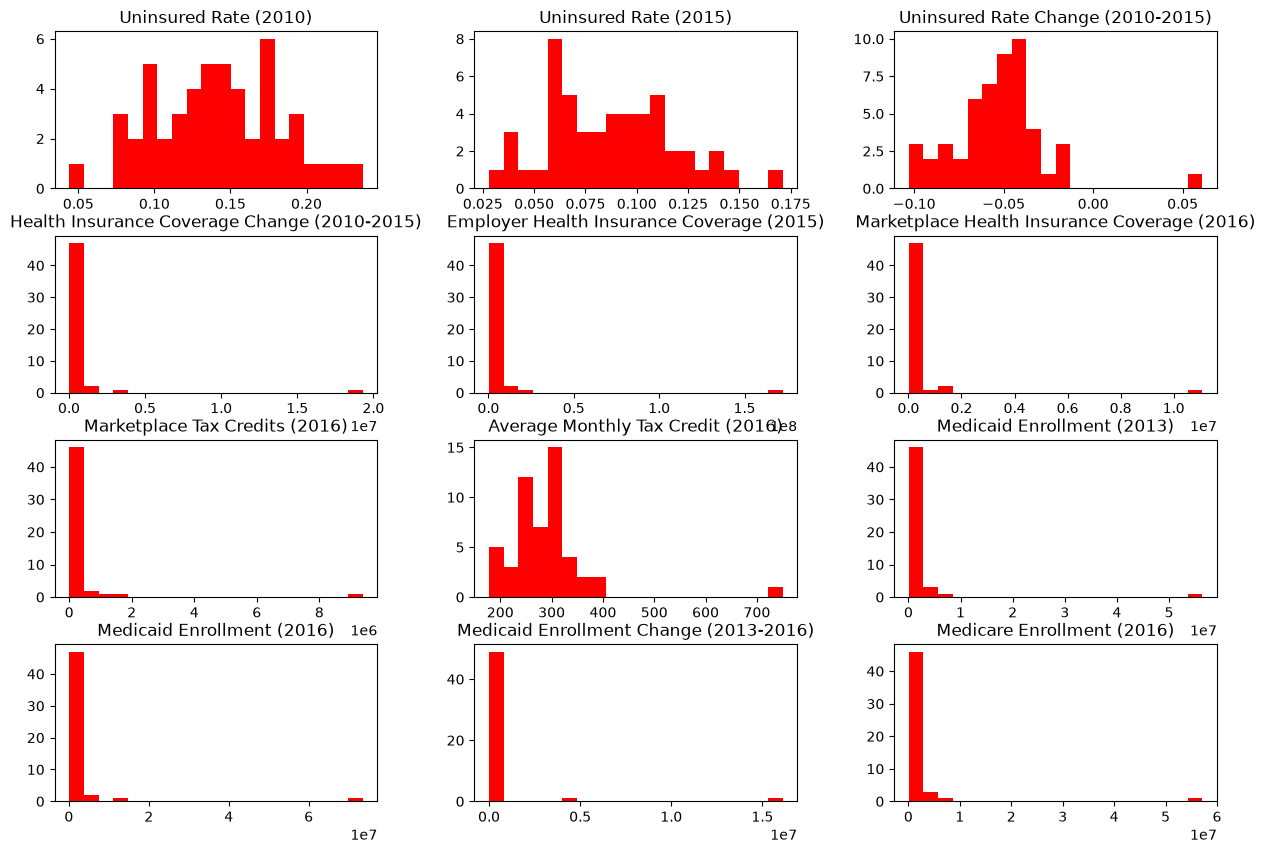

In [94]:
ndf.hist(bins=20, figsize=(15, 10), grid=False, color='red')


 Uninsured Rate (2010)
********************
count    51.000000
mean      0.141667
std       0.042043
min       0.044000
25%       0.112000
50%       0.142000
75%       0.174000
max       0.237000
Name: Uninsured Rate (2010), dtype: float64


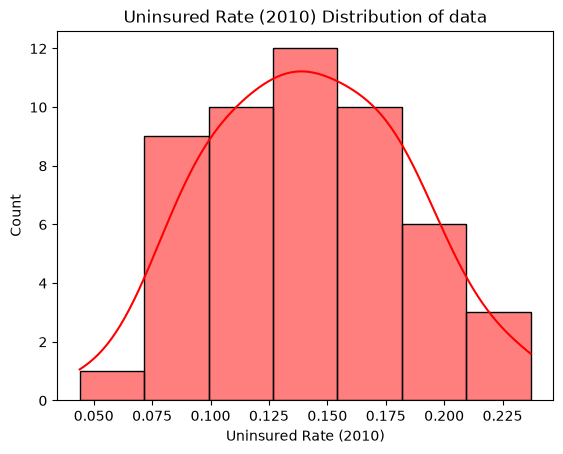


 Uninsured Rate (2015)
********************
count    51.000000
mean      0.086804
std       0.031493
min       0.028000
25%       0.062000
50%       0.086000
75%       0.108500
max       0.171000
Name: Uninsured Rate (2015), dtype: float64


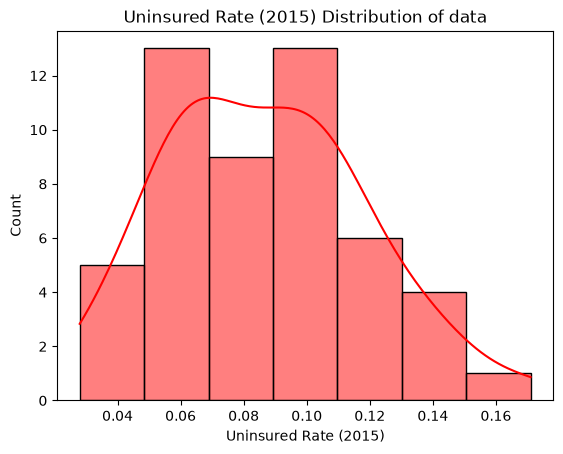


 Uninsured Rate Change (2010-2015)
********************
count    51.000000
mean     -0.052471
std       0.026633
min      -0.103000
25%      -0.066000
50%      -0.050000
75%      -0.039500
max       0.061000
Name: Uninsured Rate Change (2010-2015), dtype: float64


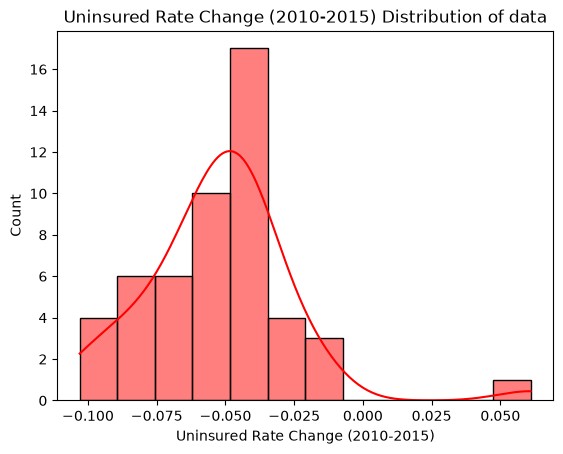


 Health Insurance Coverage Change (2010-2015)
********************
count    5.100000e+01
mean     7.622157e+05
std      2.716259e+06
min      1.500000e+04
25%      1.080000e+05
50%      2.340000e+05
75%      4.145000e+05
max      1.930400e+07
Name: Health Insurance Coverage Change (2010-2015), dtype: float64


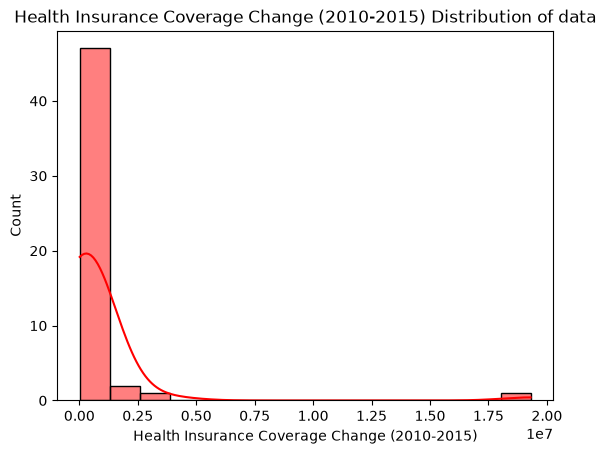


 Employer Health Insurance Coverage (2015)
********************
count    5.100000e+01
mean     6.749980e+06
std      2.392139e+07
min      3.450000e+05
25%      9.300000e+05
50%      2.316000e+06
75%      4.541000e+06
max      1.722920e+08
Name: Employer Health Insurance Coverage (2015), dtype: float64


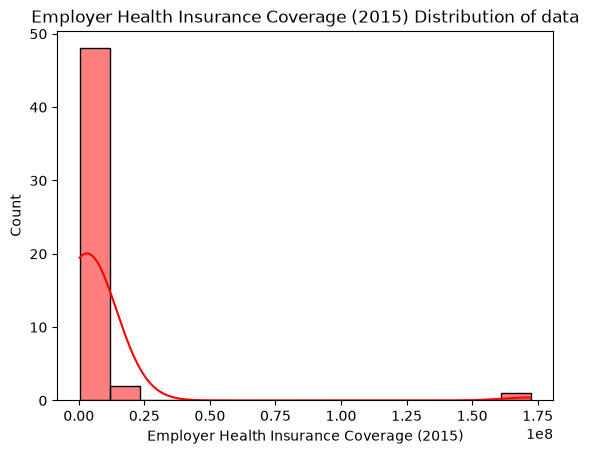


 Marketplace Health Insurance Coverage (2016)
********************
count    5.100000e+01
mean     4.341291e+05
std      1.552468e+06
min      1.331300e+04
25%      5.755750e+04
50%      1.311670e+05
75%      2.279565e+05
max      1.108133e+07
Name: Marketplace Health Insurance Coverage (2016), dtype: float64


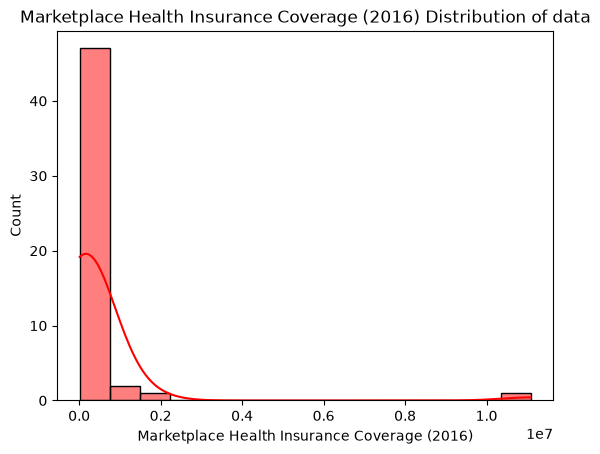


 Marketplace Tax Credits (2016)
********************
count    5.100000e+01
mean     3.678217e+05
std      1.318693e+06
min      1.224000e+03
25%      4.567850e+04
50%      1.008440e+05
75%      1.968270e+05
max      9.389609e+06
Name: Marketplace Tax Credits (2016), dtype: float64


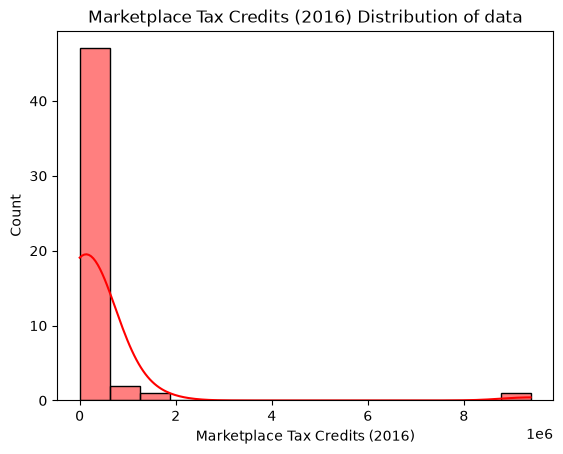


 Average Monthly Tax Credit (2016)
********************
count     51.000000
mean     288.862745
std       82.633654
min      178.000000
25%      249.000000
50%      291.000000
75%      309.500000
max      750.000000
Name: Average Monthly Tax Credit (2016), dtype: float64


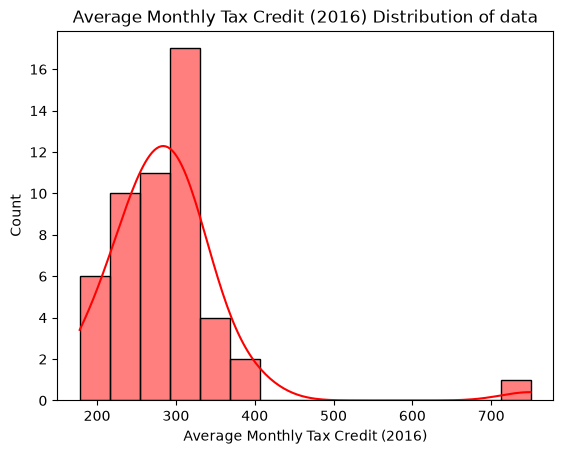


 Medicaid Enrollment (2013)
********************
count    5.100000e+01
mean     2.298605e+06
std      7.859577e+06
min      6.998000e+04
25%      3.132945e+05
50%      8.460840e+05
75%      1.415724e+06
max      5.639248e+07
Name: Medicaid Enrollment (2013), dtype: float64


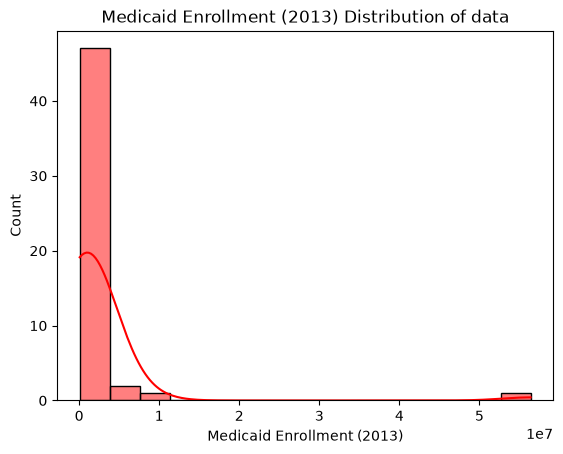


 Medicaid Enrollment (2016)
********************
count    5.100000e+01
mean     2.882398e+06
std      1.027304e+07
min      8.976300e+04
25%      3.276910e+05
50%      9.888210e+05
75%      1.749250e+06
max      7.353293e+07
Name: Medicaid Enrollment (2016), dtype: float64


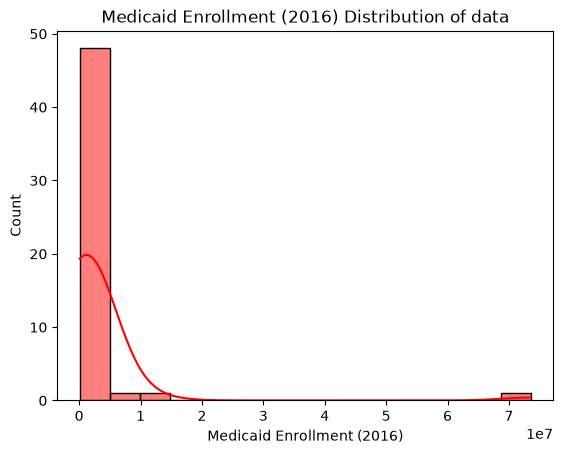


 Medicaid Enrollment Change (2013-2016)
********************
count    5.100000e+01
mean     6.569557e+05
std      2.281595e+06
min     -1.898000e+03
25%      5.619750e+04
50%      2.817380e+05
75%      4.940320e+05
max      1.610616e+07
Name: Medicaid Enrollment Change (2013-2016), dtype: float64


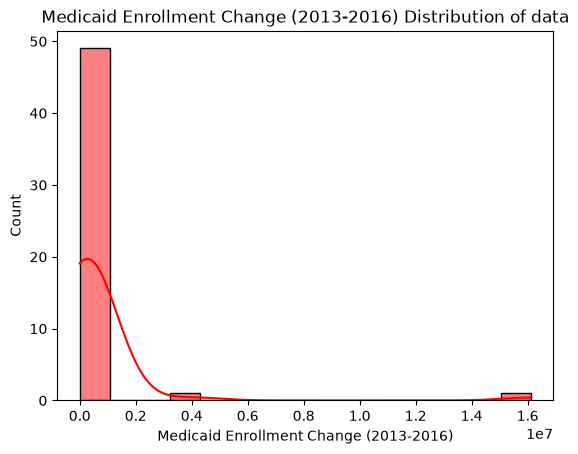


 Medicare Enrollment (2016)
********************
count    5.100000e+01
mean     2.214605e+06
std      7.928470e+06
min      8.896600e+04
25%      3.408415e+05
50%      8.202340e+05
75%      1.329590e+06
max      5.714998e+07
Name: Medicare Enrollment (2016), dtype: float64


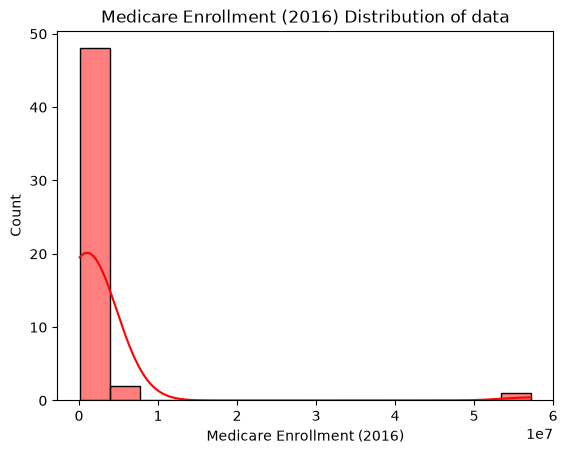

In [95]:
for col in numeric_features:
    
    print("\n",col)
    print("********************")
    print(ndf[col].describe())


    sns.histplot(ndf[col],kde=True,color="red")
    plt.title(f"{col} Distribution of data")
    plt.show()

It is clear that the most of the data is centered in the left side. This means that most of the medicaid enrollment is relativey small in the data set. This also shows that there are extreme outliers in the dataset. We need to check the dataset by using boxplot 

In [96]:
numeric_features

['Uninsured Rate (2010)',
 'Uninsured Rate (2015)',
 'Uninsured Rate Change (2010-2015)',
 'Health Insurance Coverage Change (2010-2015)',
 'Employer Health Insurance Coverage (2015)',
 'Marketplace Health Insurance Coverage (2016)',
 'Marketplace Tax Credits (2016)',
 'Average Monthly Tax Credit (2016)',
 'Medicaid Enrollment (2013)',
 'Medicaid Enrollment (2016)',
 'Medicaid Enrollment Change (2013-2016)',
 'Medicare Enrollment (2016)']

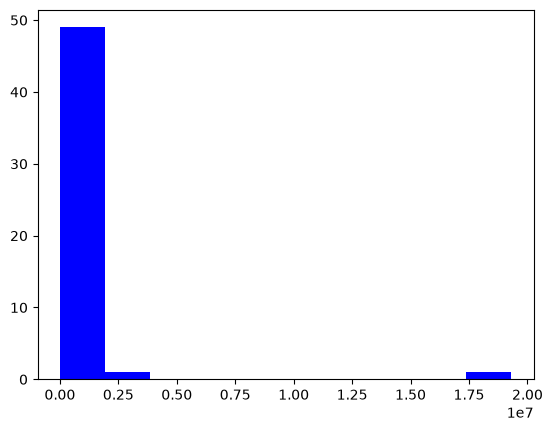

In [97]:
plt.hist(ndf['Health Insurance Coverage Change (2010-2015)'], bins=10,color="blue")
plt.show()

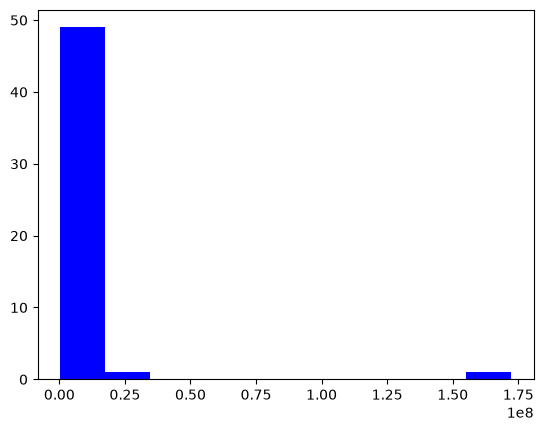

In [98]:
plt.hist(ndf['Employer Health Insurance Coverage (2015)'], bins=10,color="blue")
plt.show()

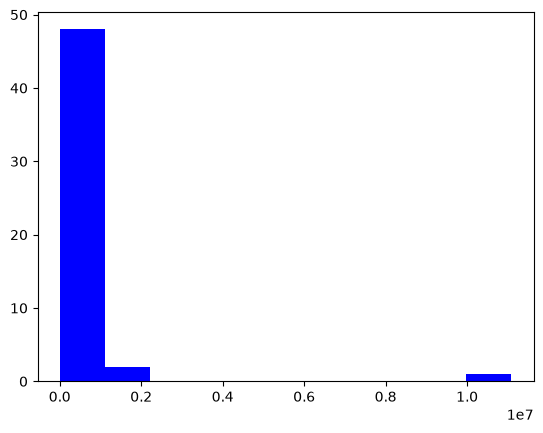

In [99]:
plt.hist(ndf['Marketplace Health Insurance Coverage (2016)'], bins=10,color="blue")
plt.show()

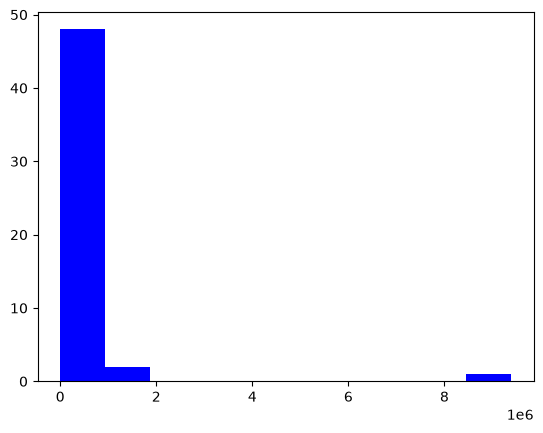

In [100]:
plt.hist(ndf['Marketplace Tax Credits (2016)'], bins=10,color="blue")
plt.show()

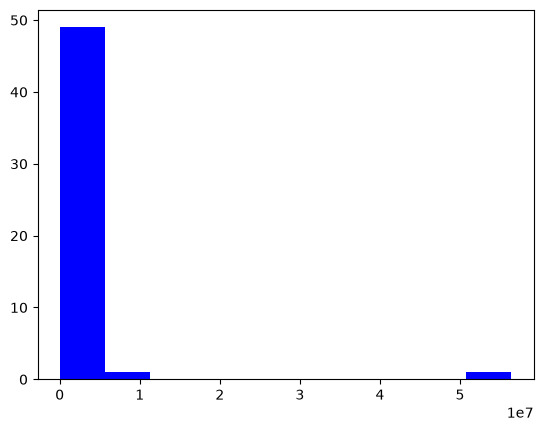

In [101]:
plt.hist(ndf['Medicaid Enrollment (2013)'], bins=10,color="blue")
plt.show()

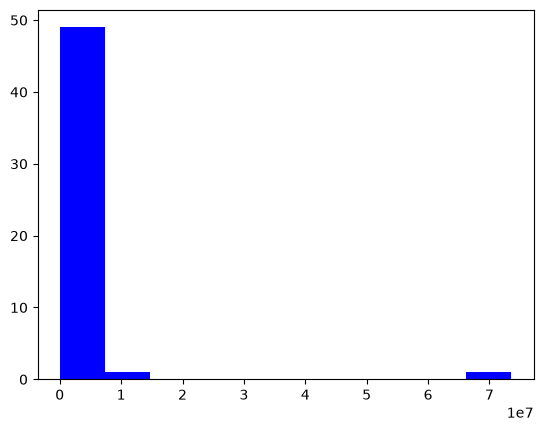

In [102]:
plt.hist(ndf['Medicaid Enrollment (2016)'], bins=10,color="blue")
plt.show()

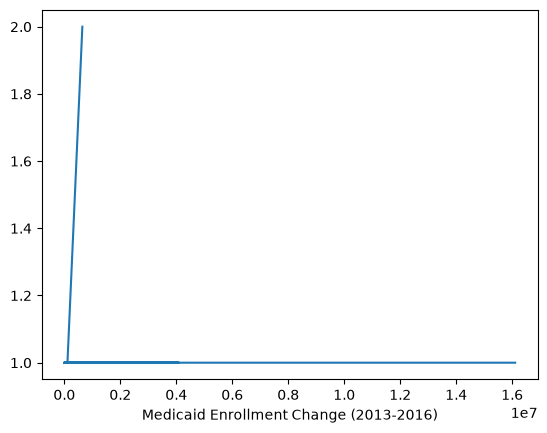

In [103]:

ndf['Medicaid Enrollment Change (2013-2016)'].value_counts().plot(kind="line")
plt.show()

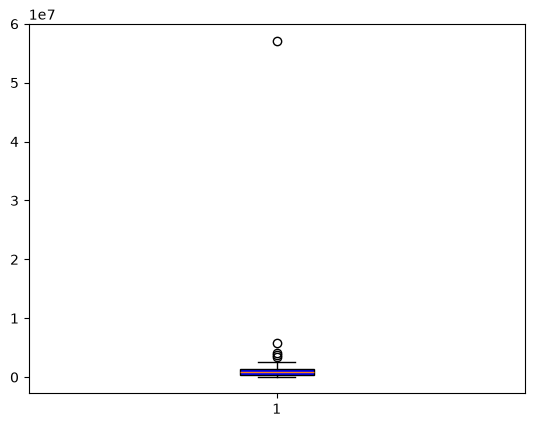

In [104]:
plt.boxplot(ndf['Medicare Enrollment (2016)'], patch_artist=True, boxprops=dict(facecolor="blue"))
plt.show()

### 4.2 Categorical data distribution

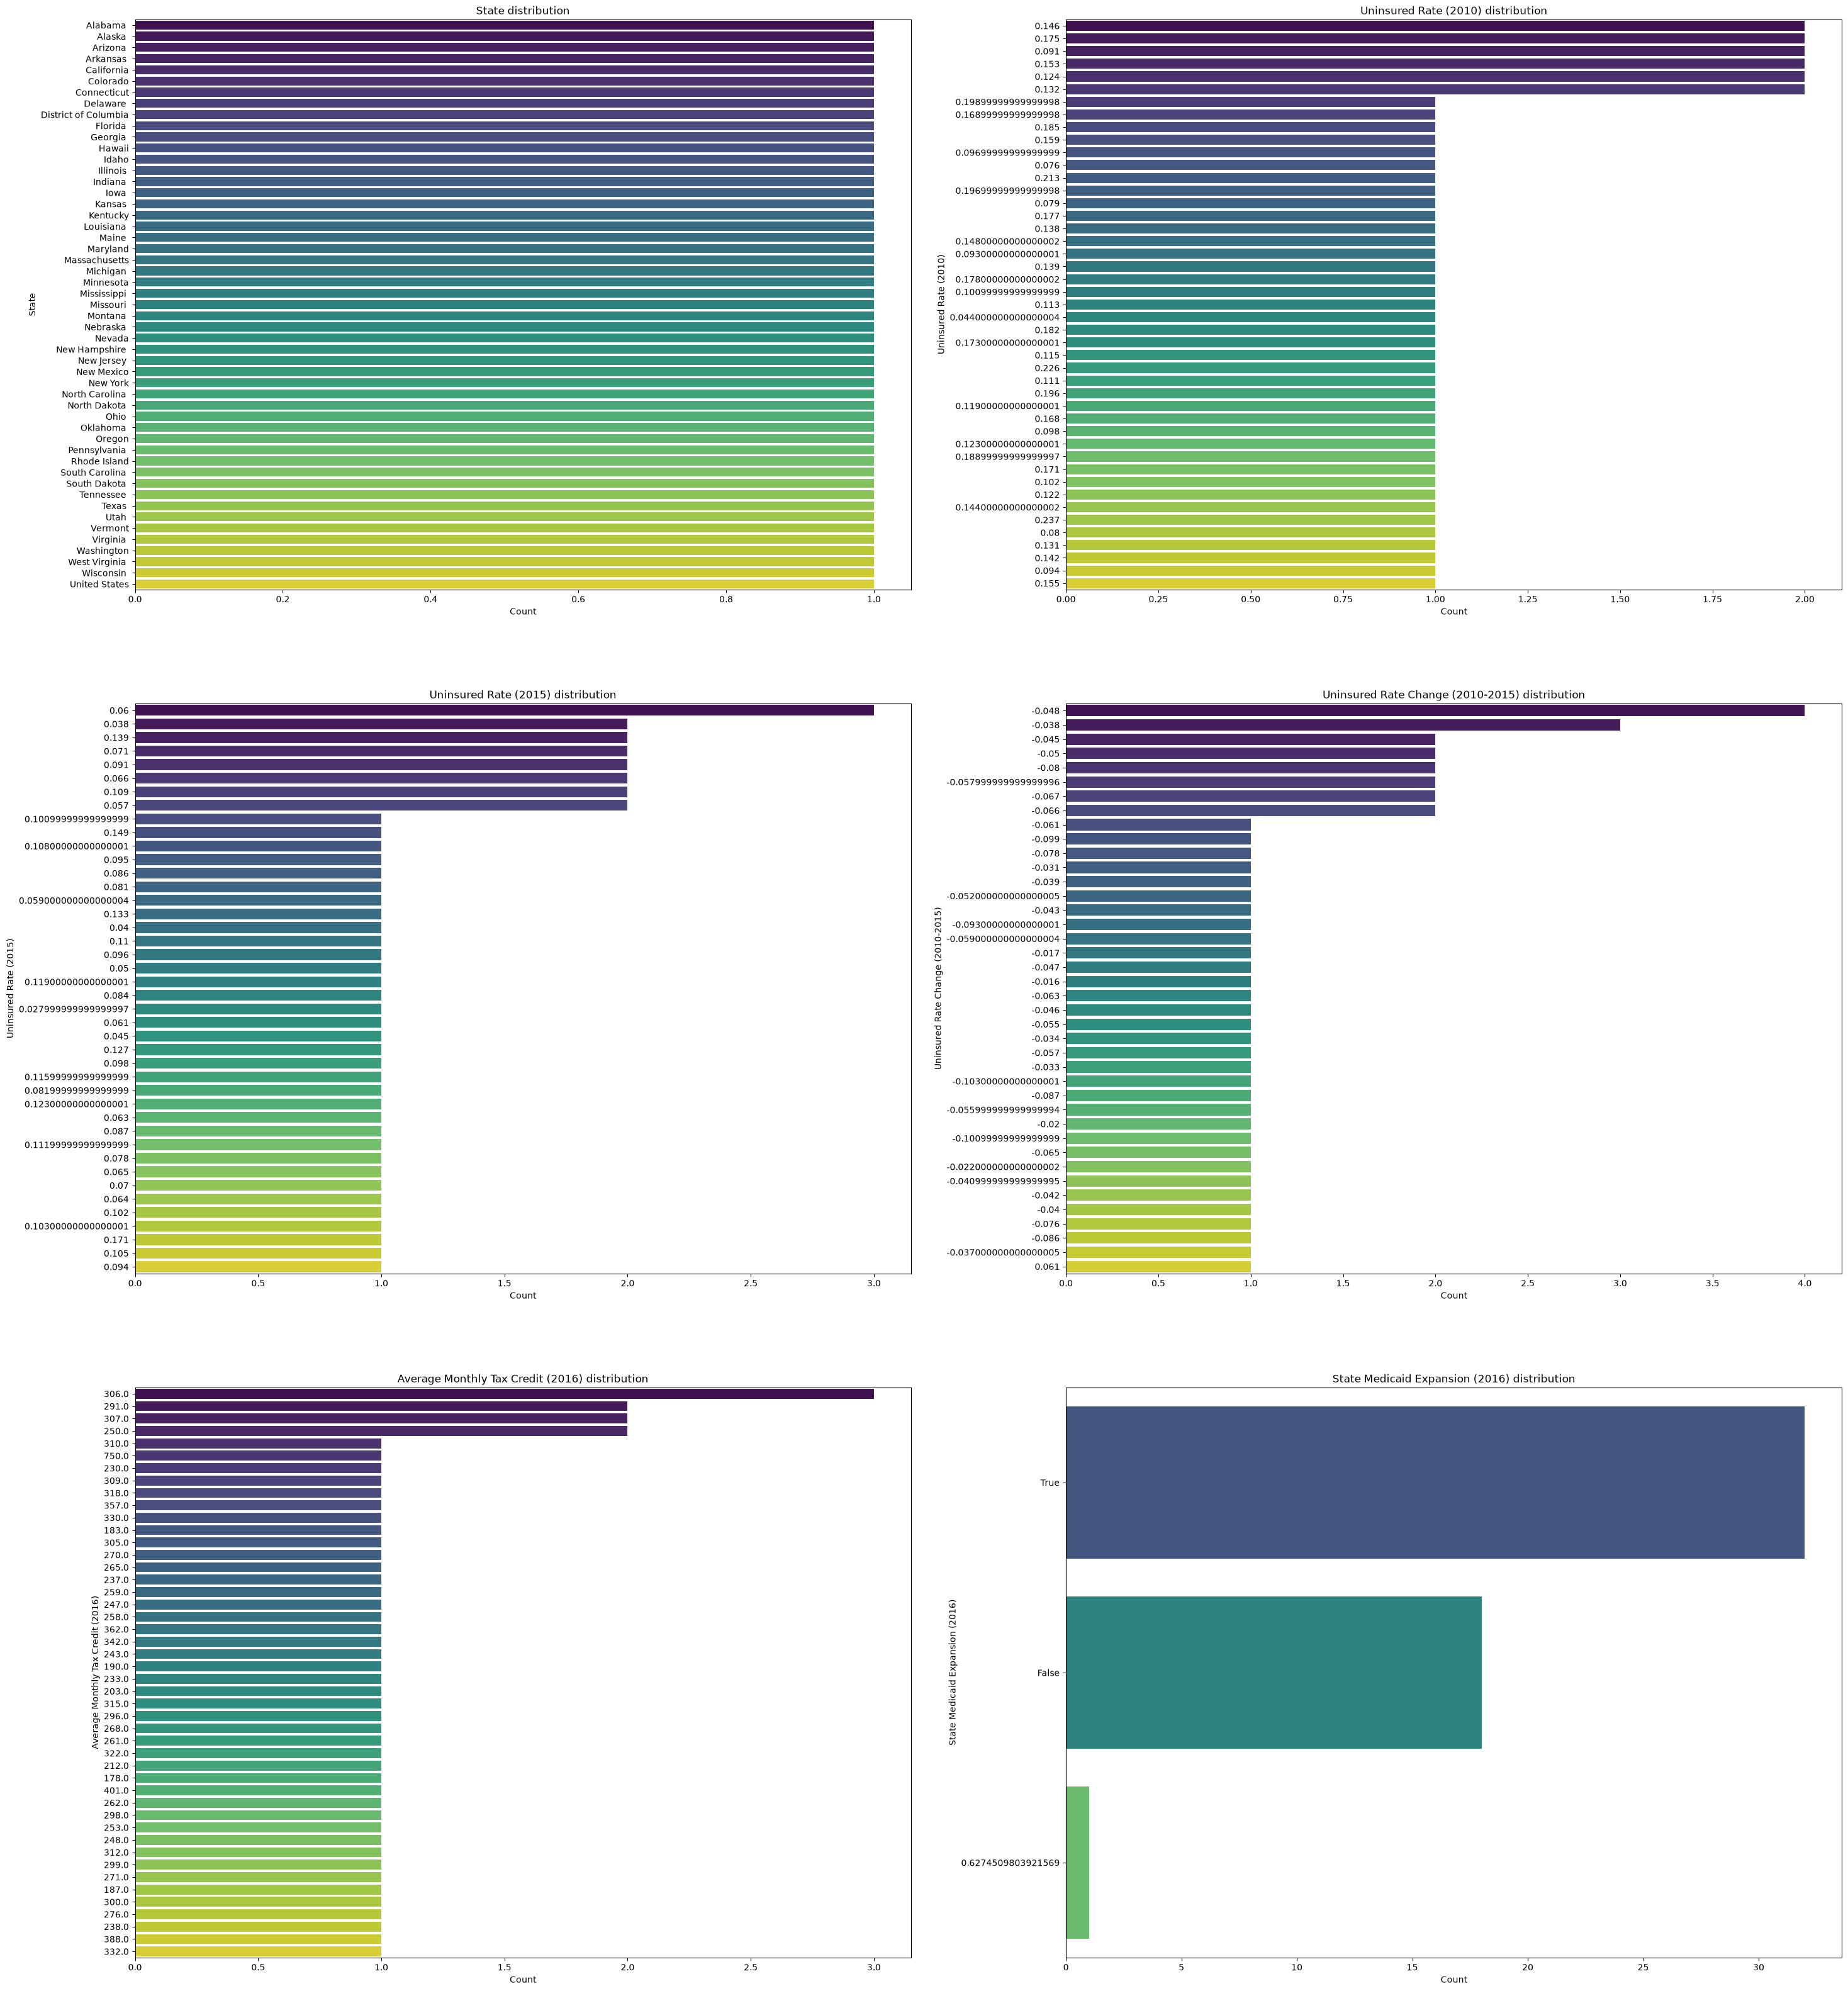

In [105]:
cat_cols = ['State', 'Uninsured Rate (2010)', 'Uninsured Rate (2015)',
            'Uninsured Rate Change (2010-2015)', 'Average Monthly Tax Credit (2016)', 'State Medicaid Expansion (2016)']

fig, axes = plt.subplots(3, 2, figsize=(35, 40))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order = ndf[col].value_counts().index
    sns.countplot(y=ndf[col], order=order, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} distribution')
    axes[i].set_xlabel('Count')

### 4.3 Categorical data


 State
********************
count           51
unique          51
top       Alabama 
freq             1
Name: State, dtype: object


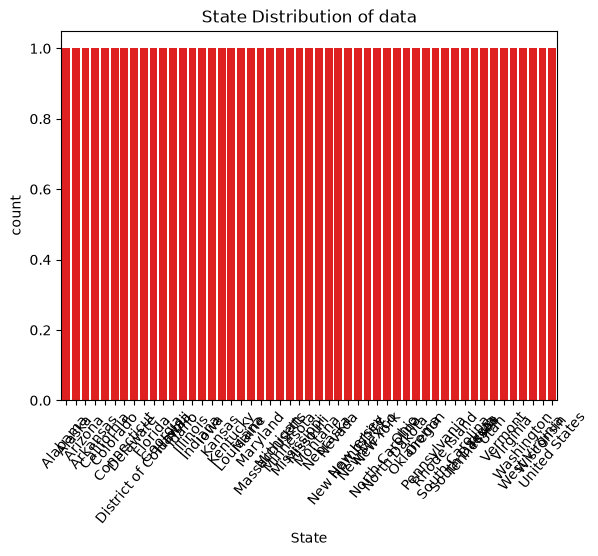


 State Medicaid Expansion (2016)
********************
count       51
unique       3
top       True
freq        32
Name: State Medicaid Expansion (2016), dtype: object


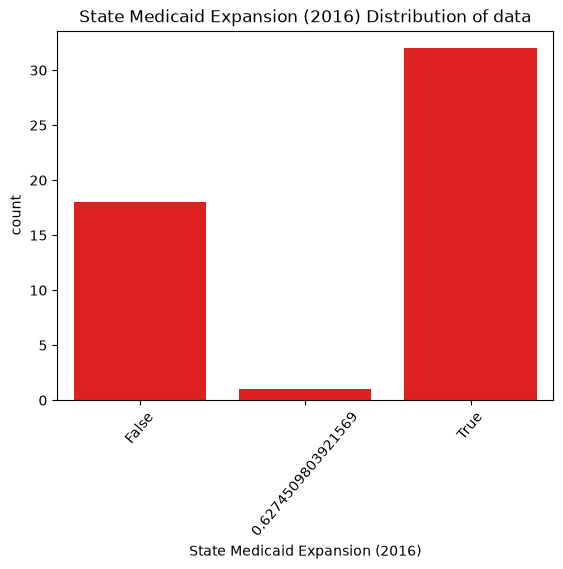

In [106]:
for col in categorical_features:
    
    print("\n",col)
    print("********************")
    print(ndf[col].describe())


    sns.countplot(x=ndf[col],color="red")
    plt.title(f"{col} Distribution of data")
    plt.xticks(rotation=50)
    plt.show()

<Axes: xlabel='State Medicaid Expansion (2016)', ylabel='Medicaid Enrollment Change (2013-2016)'>

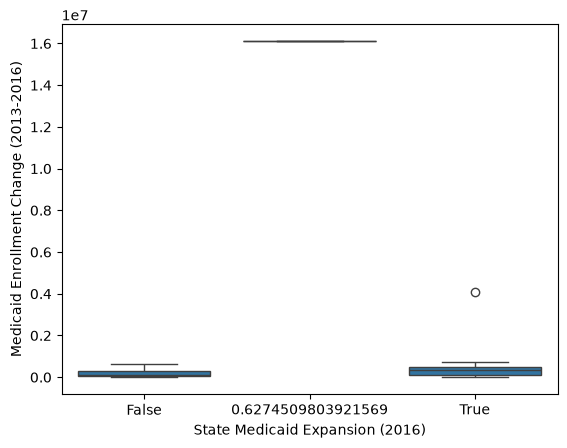

In [107]:
sns.boxplot(x='State Medicaid Expansion (2016)', y='Medicaid Enrollment Change (2013-2016)', data=ndf)

From the categorical data analysis certain interisting points can be understood:
1. In the States column, United States is again mentioned at the end which creates a massive outliers
2.The uninsured rate in the year 2010 and 2015 shows data as percentage but is received as string in the data type. 
3. The boxplot comparison between the state medicaid expansion and the enrollment change shows that certain states show very tight, minimal enrollment growth close to zero that are represented by fasle. On the other hand the the states represented by True show higher enrollment growth. These states also has a potential outlier. 
 

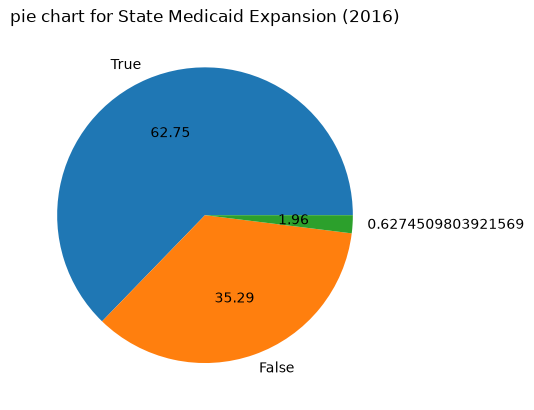

In [108]:
ndf['State Medicaid Expansion (2016)'].value_counts().plot(kind='pie', autopct='%.2f')
plt.title("pie chart for State Medicaid Expansion (2016)")
plt.show()

## 5. Bivariate Analysis
This method will help us to know the relation between the two variables within the dataset. 

# 5.1 Scatter Plot

<Axes: xlabel='Uninsured Rate (2010)', ylabel='Uninsured Rate Change (2010-2015)'>

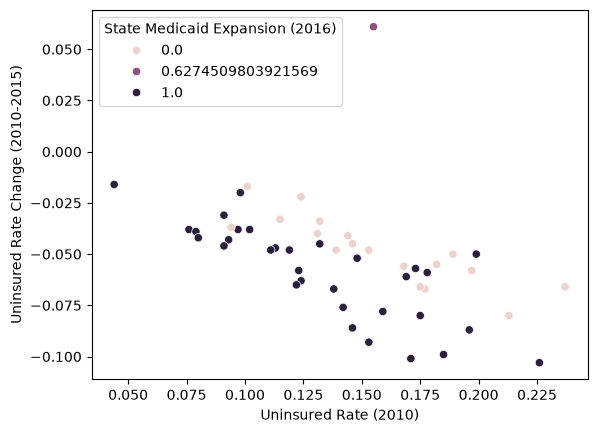

In [117]:
sns.scatterplot(x=ndf['Uninsured Rate (2010)'], y=ndf['Uninsured Rate Change (2010-2015)'], hue=ndf['State Medicaid Expansion (2016)'])

The scatterplot between Health Insurance Coverage Change (2010-2015) and State Medicaid Expansion (2016) shows that :
1. The x-axis clearly indicates the uninsured rate in the year 2010 and the y-axis reflects the rate change between 2010-2015. 
2. The state medicaid expansion is used as the color hue to understand which state expansded their medicaid and which states did not. 
3. The darker spots showed that the states fully expanded on the medicaid and the lighter spots showed the states did not expand. 

<Axes: xlabel='Medicare Enrollment (2016)', ylabel='State Medicaid Expansion (2016)'>

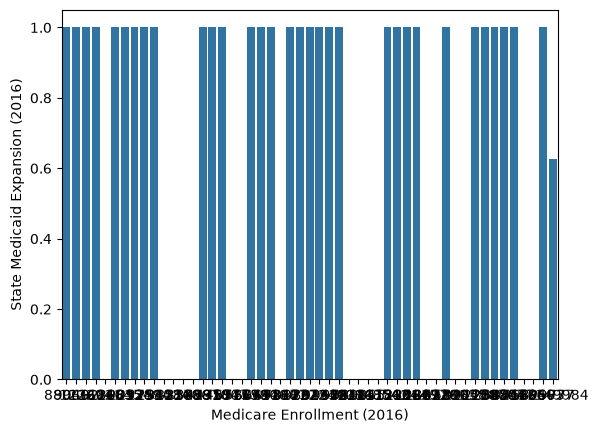

In [110]:
sns.barplot(y=ndf['State Medicaid Expansion (2016)'], x=ndf['Medicare Enrollment (2016)'])

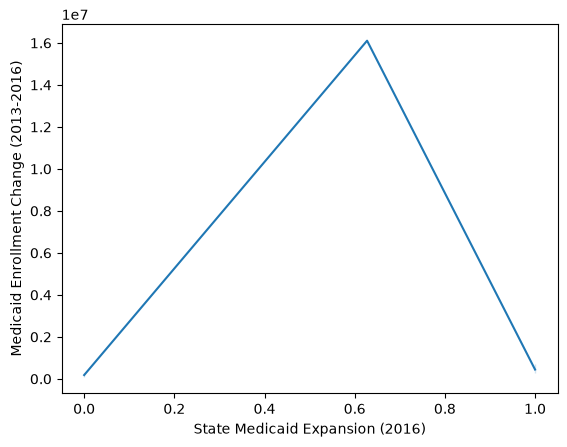

In [111]:
sns.lineplot(x=ndf["State Medicaid Expansion (2016)"],y=ndf["Medicaid Enrollment Change (2013-2016)"])

plt.show()

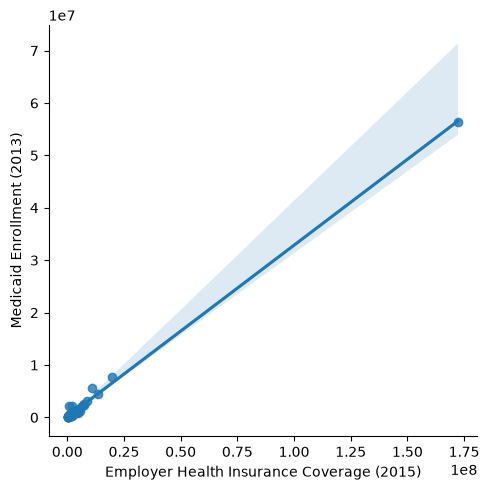

In [121]:
sns.lmplot(x="Employer Health Insurance Coverage (2015)", y="Medicaid Enrollment (2013)", data=ndf)

In the above graph the x-axis shows  the  number of people covered by employer-sponsored insurance while the y-axis measures the enrollment in medicaid. The cluster of dots at the bottom-left corner represents individual U.S. states.  The single data point on the far right is the United States national total.

## 6. Multivariate Analysis 
This helps in analysis of 3 or more variables at the same time 

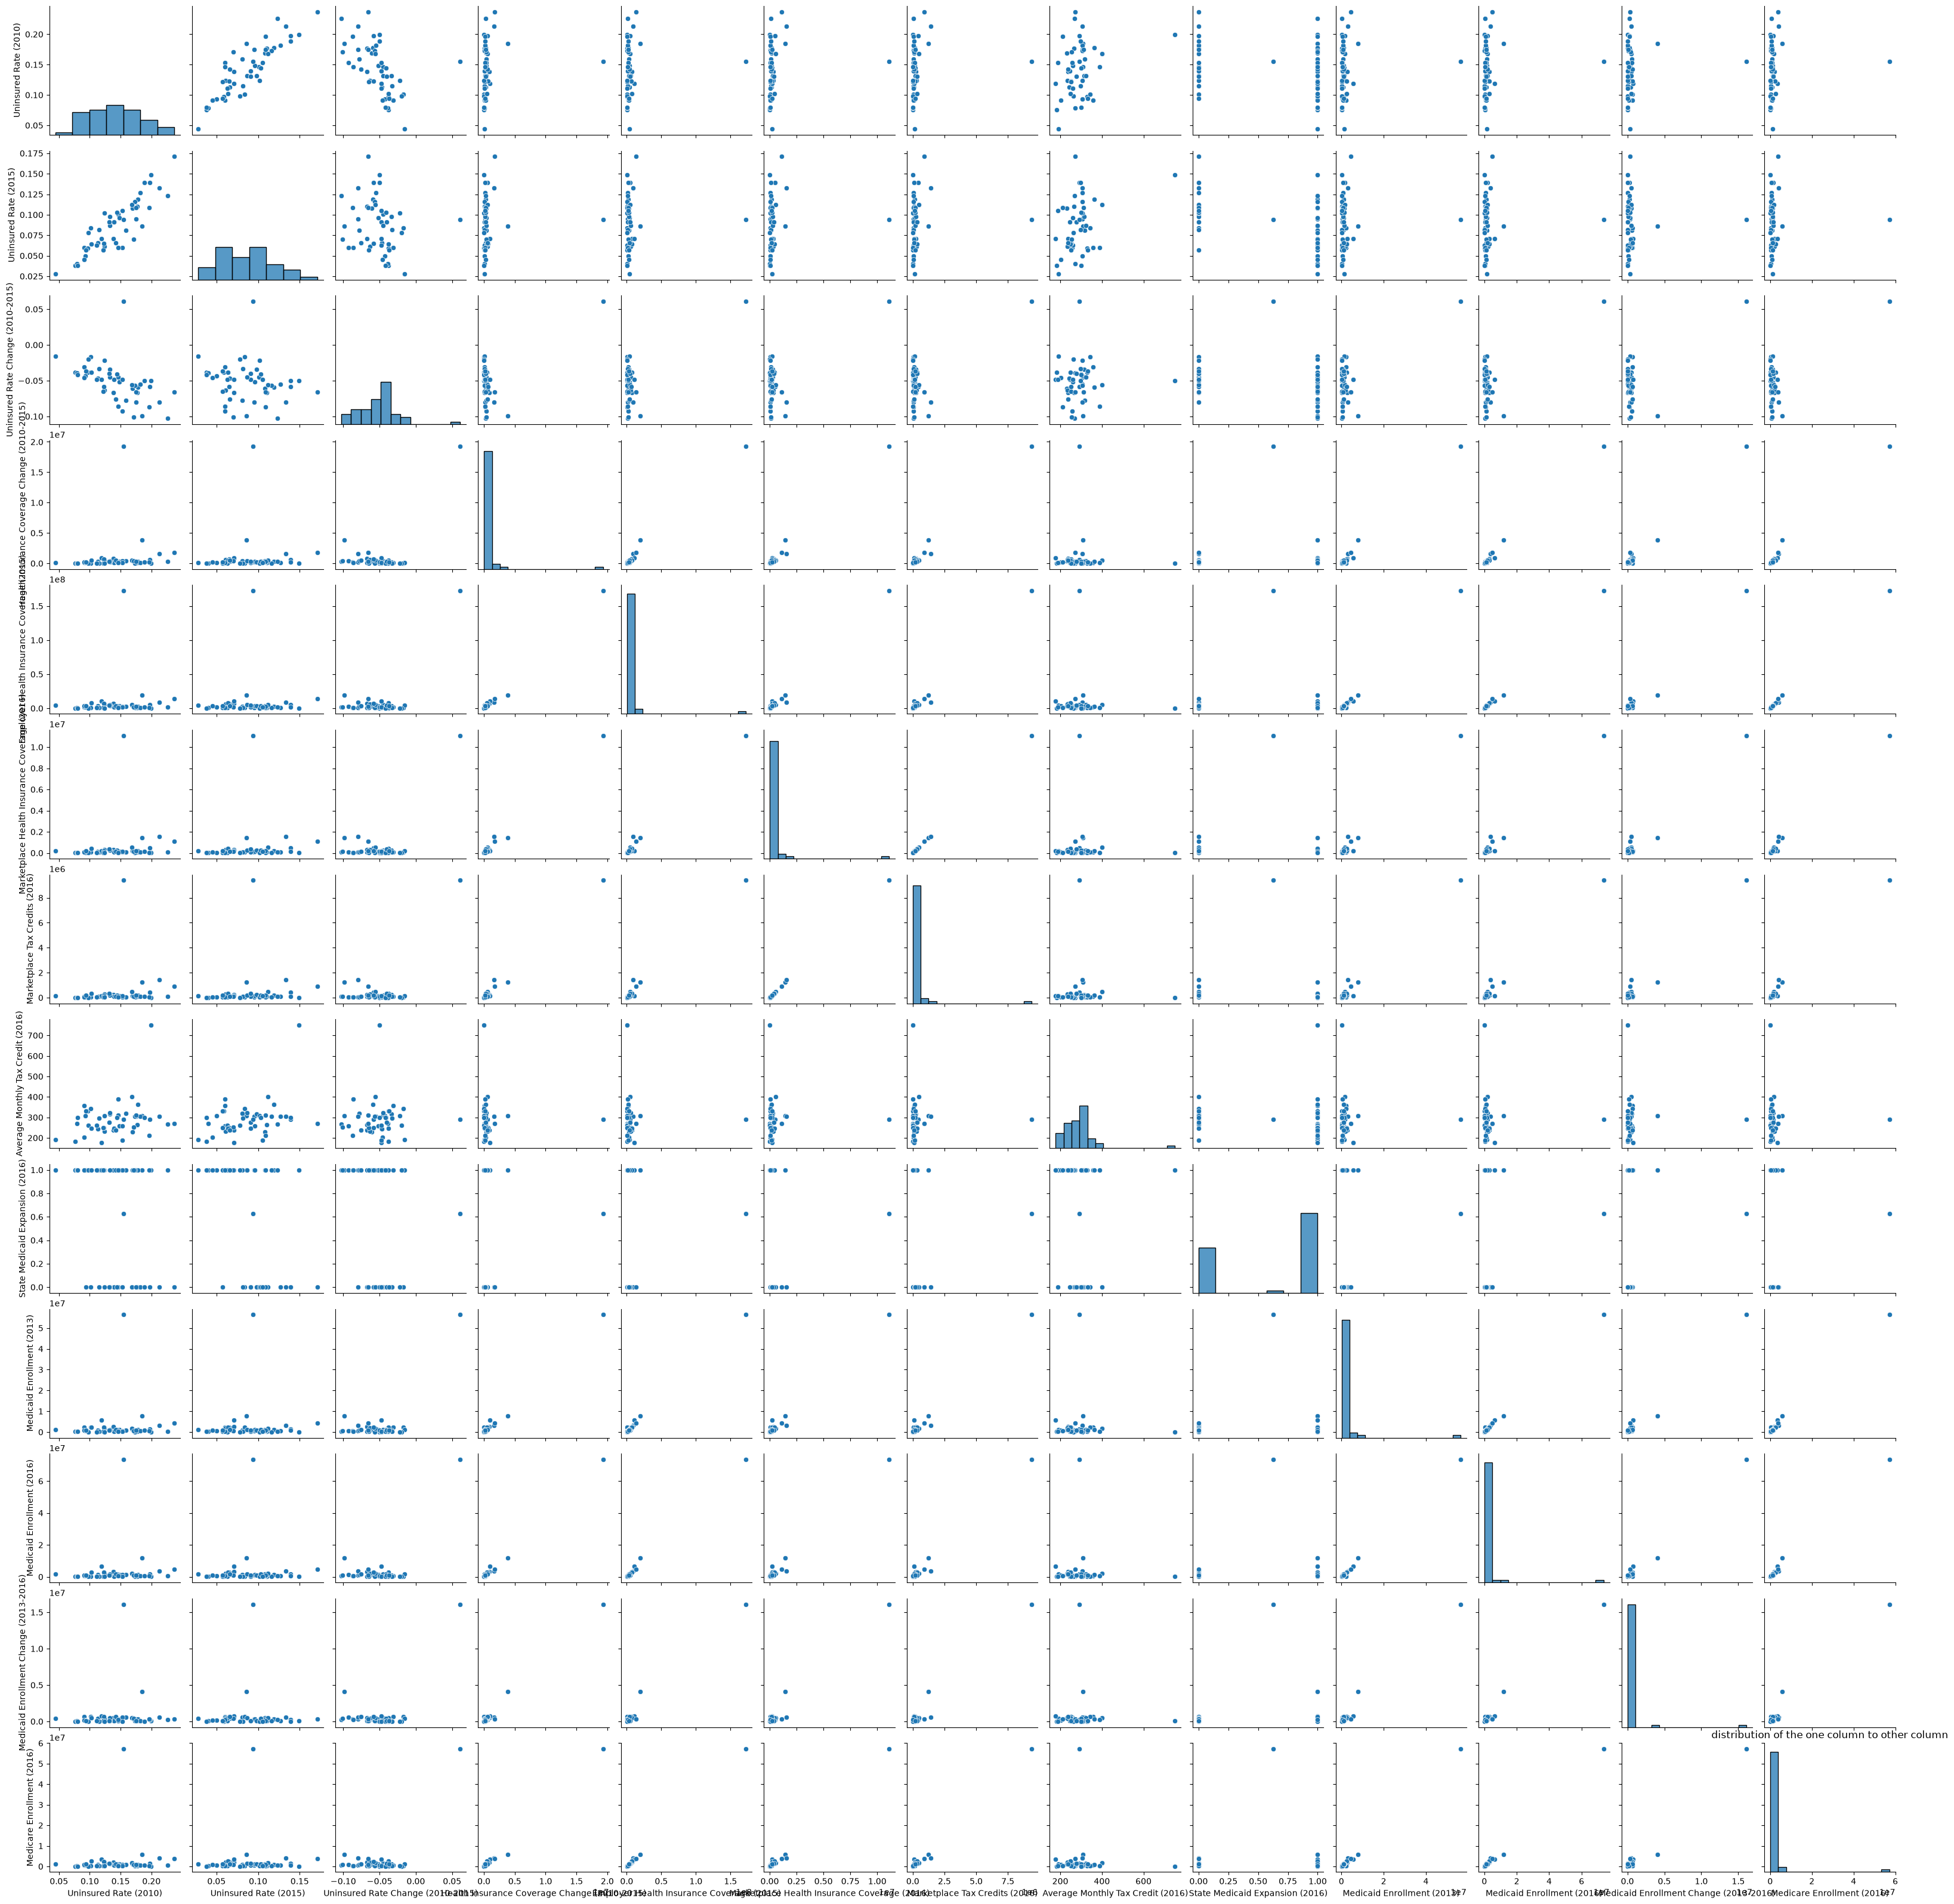

In [113]:
plt.Figure(figsize=(15,12))
sns.pairplot(ndf)
plt.title("distribution of the one column to other column")
plt.show()

In [114]:
ndf.corr(numeric_only=True)

,Uninsured Rate (2010),Uninsured Rate (2015),Uninsured Rate Change (2010-2015),Health Insurance Coverage Change (2010-2015),Employer Health Insurance Coverage (2015),Marketplace Health Insurance Coverage (2016),Marketplace Tax Credits (2016),Average Monthly Tax Credit (2016),Medicaid Enrollment (2013),Medicaid Enrollment (2016),Medicaid Enrollment Change (2013-2016),Medicare Enrollment (2016)
Uninsured Rate (2010),1.000000,0.873077,-0.517154,0.128901,0.082565,0.128213,0.134805,0.263609,0.077741,0.089110,0.085681,0.085739
Uninsured Rate (2015),0.873077,1.000000,-0.174827,0.078015,0.055640,0.103718,0.110435,0.370590,0.052199,0.049359,0.022349,0.058298
Uninsured Rate Change (2010-2015),-0.517154,-0.174827,1.000000,0.514165,0.569468,0.548578,0.544578,0.024453,0.569560,0.547773,0.511531,0.568392
Health Insurance Coverage Change (2010-2015),0.128901,0.078015,0.514165,1.000000,0.994845,0.993999,0.992918,-0.009993,0.994295,0.997137,0.991895,0.994136
Employer Health Insurance Coverage (2015),0.082565,0.055640,0.569468,0.994845,1.000000,0.993873,0.991840,-0.019482,0.997721,0.998082,0.984839,0.999484
Marketplace Health Insurance Coverage (2016),0.128213,0.103718,0.548578,0.993999,0.993873,1.000000,0.999825,0.002309,0.990710,0.991096,0.978205,0.995241
Marketplace Tax Credits (2016),0.134805,0.110435,0.544578,0.992918,0.991840,0.999825,1.000000,0.007299,0.988580,0.989083,0.976565,0.993553
Average Monthly Tax Credit (2016),0.263609,0.370590,0.024453,-0.009993,-0.019482,0.002309,0.007299,1.000000,-0.016969,-0.020248,-0.002680,-0.015362
Medicaid Enrollment (2013),0.077741,0.052199,0.569560,0.994295,0.997721,0.990710,0.988580,-0.016969,1.000000,0.998341,0.987699,0.997145
Medicaid Enrollment (2016),0.089110,0.049359,0.547773,0.997137,0.998082,0.991096,0.989083,-0.020248,0.998341,1.000000,0.991439,0.997331


<Axes: >

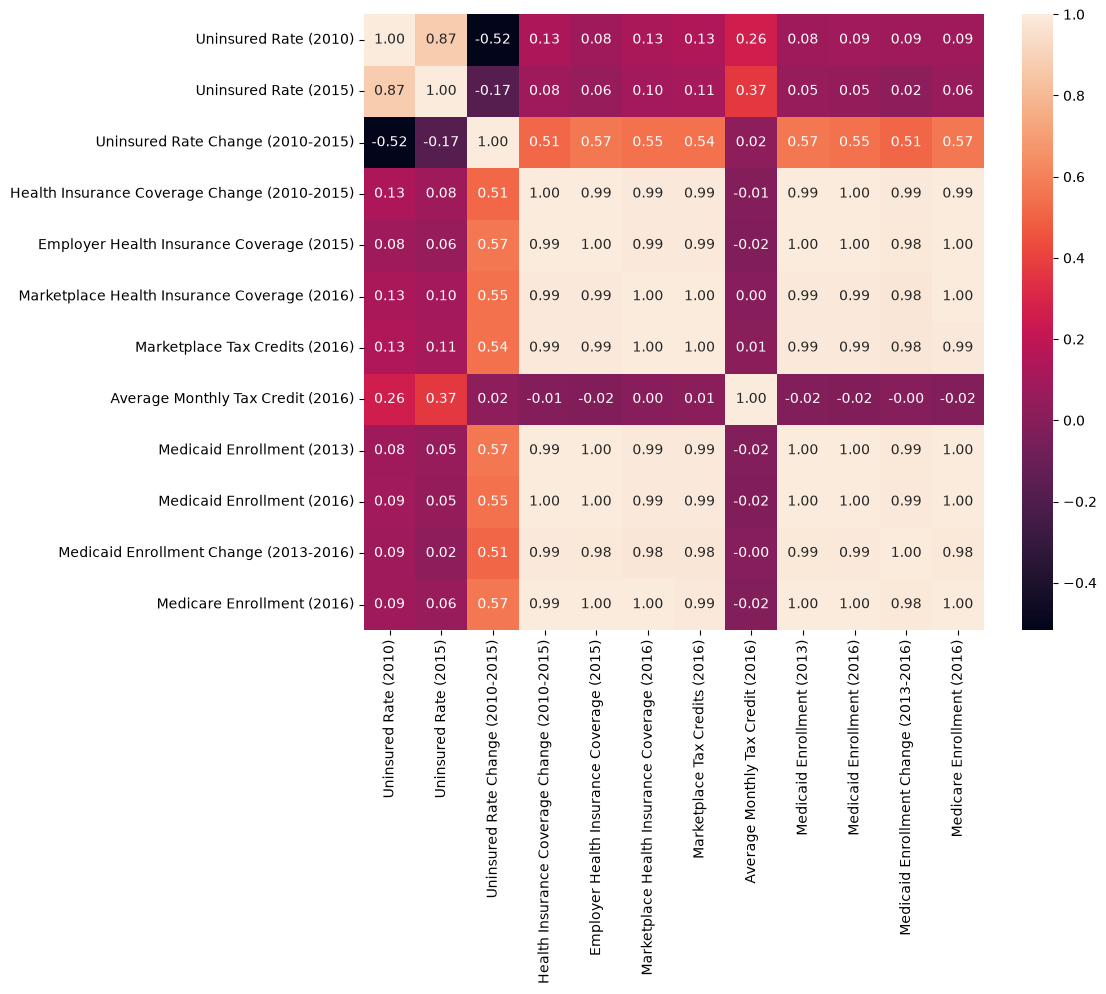

In [115]:
plt.figure(figsize=(10,8))
sns.heatmap(ndf.corr(numeric_only=True),fmt=".2f",annot=True)

The uninsured rate change (2010-2015) versus Uninsured Rate (2010) shows a strong negative correlation. This shows that states witrh higher uninsured rates achieved the largest drops in uninsured rates by 2015.
There is a moderate positive correlation between Average Monthly Tax Credit (2016) vs. Uninsured Rate 2015. States with higher uninsured rates by 2015 tended to see higher average monthly tax credits being utilized by 2016. 

## 7. Outlier detection and removal


In [134]:
Q1 = ndf[numeric_features].quantile(0.25)
Q2 = ndf[numeric_features].quantile(0.75)


iqr = Q2 - Q1

lower_bound = Q1 - 1.5 * iqr
upper_bound = Q2 + 1.5 * iqr

print('Q1:', Q1)
print('Q2:', Q2)
print('IQR:', iqr)
print('Lower Bound:', lower_bound)
print('Upper Bound:', upper_bound)

Q1: Uninsured Rate (2010)                                0.112
Uninsured Rate (2015)                                0.062
Uninsured Rate Change (2010-2015)                   -0.066
Health Insurance Coverage Change (2010-2015)    108000.000
Employer Health Insurance Coverage (2015)       930000.000
Marketplace Health Insurance Coverage (2016)     57557.500
Marketplace Tax Credits (2016)                   45678.500
Average Monthly Tax Credit (2016)                  249.000
Medicaid Enrollment (2013)                      313294.500
Medicaid Enrollment (2016)                      327691.000
Medicaid Enrollment Change (2013-2016)           56197.500
Medicare Enrollment (2016)                      340841.500
Name: 0.25, dtype: float64
Q2: Uninsured Rate (2010)                           1.740000e-01
Uninsured Rate (2015)                           1.085000e-01
Uninsured Rate Change (2010-2015)              -3.950000e-02
Health Insurance Coverage Change (2010-2015)    4.145000e+05
Employer Heal

In [144]:
Q1 = ndf["Uninsured Rate (2010)"].quantile(0.25)
Q3 = ndf["Uninsured Rate (2010)"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ndf[
    (ndf["Uninsured Rate (2010)"] < lower_bound)
    | (ndf["Uninsured Rate (2010)"] > upper_bound)
]
outliers[:5]

,State,Uninsured Rate (2010),Uninsured Rate (2015),Uninsured Rate Change (2010-2015),Health Insurance Coverage Change (2010-2015),Employer Health Insurance Coverage (2015),Marketplace Health Insurance Coverage (2016),Marketplace Tax Credits (2016),Average Monthly Tax Credit (2016),State Medicaid Expansion (2016),Medicaid Enrollment (2013),Medicaid Enrollment (2016),Medicaid Enrollment Change (2013-2016),Medicare Enrollment (2016)


In [145]:
Q1 = ndf["Uninsured Rate (2015)"].quantile(0.25)
Q3 = ndf["Uninsured Rate (2015)"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ndf[
    (ndf["Uninsured Rate (2015)"] < lower_bound)
    | (ndf["Uninsured Rate (2015)"] > upper_bound)
]
outliers[:5]

,State,Uninsured Rate (2010),Uninsured Rate (2015),Uninsured Rate Change (2010-2015),Health Insurance Coverage Change (2010-2015),Employer Health Insurance Coverage (2015),Marketplace Health Insurance Coverage (2016),Marketplace Tax Credits (2016),Average Monthly Tax Credit (2016),State Medicaid Expansion (2016),Medicaid Enrollment (2013),Medicaid Enrollment (2016),Medicaid Enrollment Change (2013-2016),Medicare Enrollment (2016)


In [146]:
Q1 = ndf["State Medicaid Expansion (2016)"].quantile(0.25)
Q3 = ndf["State Medicaid Expansion (2016)"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ndf[
    (ndf["State Medicaid Expansion (2016)"] < lower_bound)
    | (ndf["State Medicaid Expansion (2016)"] > upper_bound)
]
outliers[:5]

,State,Uninsured Rate (2010),Uninsured Rate (2015),Uninsured Rate Change (2010-2015),Health Insurance Coverage Change (2010-2015),Employer Health Insurance Coverage (2015),Marketplace Health Insurance Coverage (2016),Marketplace Tax Credits (2016),Average Monthly Tax Credit (2016),State Medicaid Expansion (2016),Medicaid Enrollment (2013),Medicaid Enrollment (2016),Medicaid Enrollment Change (2013-2016),Medicare Enrollment (2016)


In [148]:
numeric_cols = ndf.select_dtypes(include=["number"]).columns
print("--- Outlier Detection Scan ---")
for col in numeric_cols:
    Q1 = ndf[col].quantile(0.25)
    Q3 = ndf[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    has_outliers = ((ndf[col] < lower_bound) | (ndf[col] > upper_bound)).any()

    if has_outliers:
        n_out = ((ndf[col] < lower_bound) | (ndf[col] > upper_bound)).sum()
        print(f"'{col}' HAS outliers ({n_out} found)")
    else:
        print(f"'{col}' has NO outliers")

--- Outlier Detection Scan ---
'Uninsured Rate (2010)' has NO outliers
'Uninsured Rate (2015)' has NO outliers
'Uninsured Rate Change (2010-2015)' HAS outliers (1 found)
'Health Insurance Coverage Change (2010-2015)' HAS outliers (5 found)
'Employer Health Insurance Coverage (2015)' HAS outliers (4 found)
'Marketplace Health Insurance Coverage (2016)' HAS outliers (5 found)
'Marketplace Tax Credits (2016)' HAS outliers (6 found)
'Average Monthly Tax Credit (2016)' HAS outliers (2 found)
'Medicaid Enrollment (2013)' HAS outliers (5 found)
'Medicaid Enrollment (2016)' HAS outliers (4 found)
'Medicaid Enrollment Change (2013-2016)' HAS outliers (2 found)
'Medicare Enrollment (2016)' HAS outliers (5 found)


In [150]:
cleaned_ndf = ndf.copy()
numeric_cols = cleaned_ndf.select_dtypes(include=["number"]).columns

valid_rows_mask = pd.Series(True, index=cleaned_ndf.index)

for col in numeric_cols:
   
    Q1 = cleaned_ndf[col].quantile(0.25)
    Q3 = cleaned_ndf[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    inlier_mask = (cleaned_ndf[col] >= lower_bound) & (
        cleaned_ndf[col] <= upper_bound
    )
    valid_rows_mask = valid_rows_mask & inlier_mask

cleaned_ndf = cleaned_ndf[valid_rows_mask]

print(f"Original row count: {len(ndf)}")
print(f"Cleaned row count:  {len(cleaned_ndf)}")
print(f"Removed {len(ndf) - len(cleaned_ndf)} rows containing outliers.\n")

print("--- CLEANED DATASET ---")
print(cleaned_ndf)

Original row count: 51
Cleaned row count:  43
Removed 8 rows containing outliers.

--- CLEANED DATASET ---
                   State  Uninsured Rate (2010)  Uninsured Rate (2015)  \
0               Alabama                   0.146                  0.101   
2               Arizona                   0.169                  0.108   
3              Arkansas                   0.175                  0.095   
5               Colorado                  0.159                  0.081   
6            Connecticut                  0.091                  0.060   
7              Delaware                   0.097                  0.059   
8   District of Columbia                  0.076                  0.038   
11                Hawaii                  0.079                  0.040   
12                 Idaho                  0.177                  0.110   
13             Illinois                   0.138                  0.071   
14              Indiana                   0.148                  0.096   
15   